# QR Code Phishing Detection using Machine Learning

This project focuses on detecting phishing attacks embedded within QR codes by analyzing the URLs extracted from them. Since QR codes primarily encode URLs, the problem is approached as a URL-based phishing detection task.

The objective is to build a machine learning system that can classify whether a given URL is legitimate or phishing based on extracted features.

## Dataset
- Phishing URLs were obtained from PhishTank, which provides verified real-world phishing data.
- Legitimate URLs were obtained from Tranco, which contains a list of popular and trusted websites.

The datasets were combined and labeled as:
- 1 → Phishing
- 0 → Legitimate

In [7]:
!wget http://data.phishtank.com/data/online-valid.csv

!wget https://tranco-list.eu/top-1m.csv.zip
!unzip top-1m.csv.zip

--2026-03-27 21:59:29--  http://data.phishtank.com/data/online-valid.csv
Resolving data.phishtank.com (data.phishtank.com)... 104.18.162.237, 104.18.161.237
Connecting to data.phishtank.com (data.phishtank.com)|104.18.162.237|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.phishtank.com/data/online-valid.csv [following]
--2026-03-27 21:59:29--  https://data.phishtank.com/data/online-valid.csv
Connecting to data.phishtank.com (data.phishtank.com)|104.18.162.237|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn.phishtank.com/datadumps/verified_online.csv?Expires=1774628980&Signature=f~VoBFNsFxg1yDUfUQteraoj1bD8QxX~jO8R7ey3l85oIFfSHO0HsckE~lNahoHNoCqodVqzgfM7x2xtrl74aYBcf1K0f7NGB84-bBmg-mvOh-EFabfE02qSeiwYY~JQQToO2wNyj2ImKVb9~IcsedWb3j~BvmzWBw0M0rytDx9Ecyl-Mvm~3HwFyR1RHd4ucil21aAxtT8Av-HQ3-d1~NmFzP8yCqNi0dZnoFf6dZAFktLTNsy9cfxhz443S9n09ZE8gEoD-MqIpZhDrYEn4M8rVbaB13NI-Gn8Hv2fn7KxcPq6GC4I4lmynAec

In [12]:
!pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

You should consider upgrading via the '/Users/gayathriravindran/Desktop/QR-phishing-detection/.venv/bin/python3 -m pip install --upgrade pip' command.


In [13]:
# phishing data (PhishTank)
phish_df = pd.read_csv('online-valid.csv')

# legit data (Tranco)
tranco_df = pd.read_csv('top-1m.csv', header=None)
tranco_df.columns = ['rank', 'domain']

In [ ]:
print(phish_df.columns)

Index(['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified',
       'verification_time', 'online', 'target'],
      dtype='object')


In [16]:
print(tranco_df.columns)

Index(['rank', 'domain'], dtype='object')



## Data Preprocessing
The dataset required preprocessing steps such as:
- Filtering verified and active phishing URLs
- Constructing full URLs for legitimate domains
- Removing unnecessary columns
- Label assignment
- Dataset balancing and shuffling


clean phishing data (PhishTank):

In [17]:
phish_df = phish_df[['url', 'verified', 'online']]

# keep only real active phishing
phish_df = phish_df[
    (phish_df['verified'] == 'yes') &
    (phish_df['online'] == 'yes')
]

phish_df['label'] = 1
phish_df = phish_df[['url', 'label']]

clean legit data (Tranco):

In [18]:
# take only top N (to match phishing size)
tranco_df = tranco_df.head(len(phish_df))

tranco_df['url'] = 'http://' + tranco_df['domain']
tranco_df['label'] = 0

legit_df = tranco_df[['url', 'label']]

combine the datasets

In [19]:
df = pd.concat([phish_df, legit_df])

# shuffle
df = df.sample(frac=1).reset_index(drop=True)

print(df['label'].value_counts())

label
0    56143
1    56143
Name: count, dtype: int64



## Feature Extraction
Instead of using raw URLs, meaningful numerical features were extracted, including:
- URL length
- Number of dots and subdirectories
- Presence of special characters (@, -)
- Use of HTTPS
- Presence of suspicious keywords (login, verify, etc.)
- Detection of IP-based URLs

These features help distinguish phishing URLs from legitimate ones.


In [20]:
def extract_features(url):
    features = []

    # Length of URL
    features.append(len(url))

    # Number of dots
    features.append(url.count('.'))

    # Presence of @
    features.append(1 if '@' in url else 0)

    # Presence of -
    features.append(1 if '-' in url else 0)

    # Number of subdirectories
    features.append(url.count('/'))

    # HTTPS
    features.append(1 if 'https' in url else 0)

    # Digits count
    features.append(sum(c.isdigit() for c in url))

    # Suspicious words
    suspicious_words = ['login', 'verify', 'bank', 'secure', 'account']
    features.append(sum(word in url.lower() for word in suspicious_words))

    # IP address usage
    ip_pattern = r'http[s]?://\d+\.\d+\.\d+\.\d+'
    features.append(1 if re.search(ip_pattern, url) else 0)

    return features

In [21]:
X = df['url'].apply(extract_features)
X = pd.DataFrame(X.tolist())

y = df['label']

train-test split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Models Used
Five machine learning models were trained and evaluated:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

In [25]:
evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000))
evaluate_model("Decision Tree", DecisionTreeClassifier())
evaluate_model("Random Forest", RandomForestClassifier())
evaluate_model("KNN", KNeighborsClassifier())
evaluate_model("SVM", SVC())


## Evaluation Metrics
The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score

Additionally, visualizations such as:
- Model comparison graphs
- ROC curves
- Confusion matrices

were used for performance analysis.


In [26]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.996571,0.999108,0.994052,0.996574
1,Decision Tree,0.996794,0.998663,0.994940,0.996798
2,Random Forest,0.996794,0.998486,0.995118,0.996799
3,KNN,0.995859,0.998216,0.993520,0.995862
4,SVM,0.991629,0.999549,0.983755,0.991589


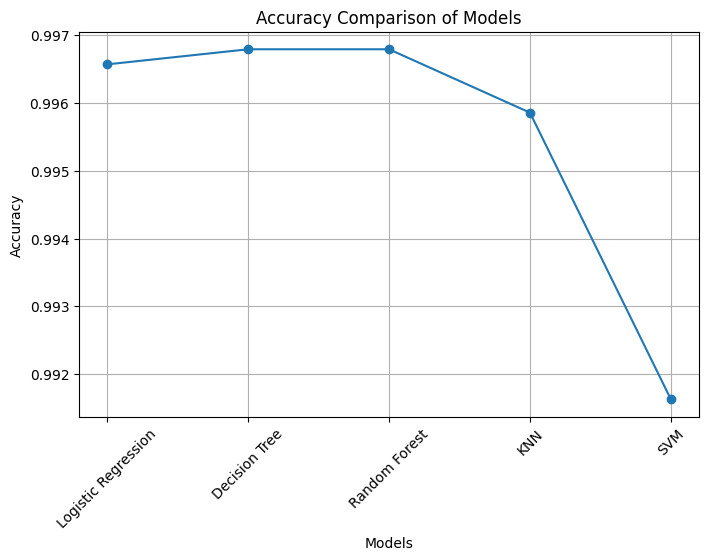

In [27]:
plt.figure(figsize=(8,5))
plt.plot(results_df["Model"], results_df["Accuracy"], marker='o')
plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid()
plt.show()

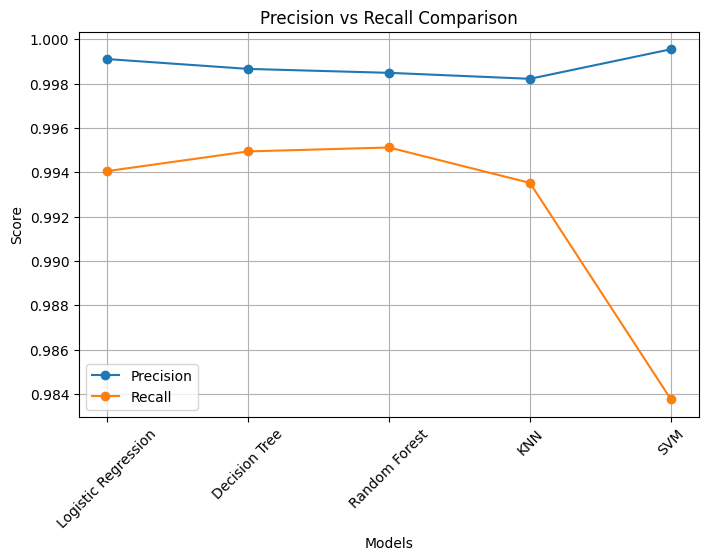

In [28]:
plt.figure(figsize=(8,5))
plt.plot(results_df["Model"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Model"], results_df["Recall"], marker='o', label="Recall")

plt.title("Precision vs Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

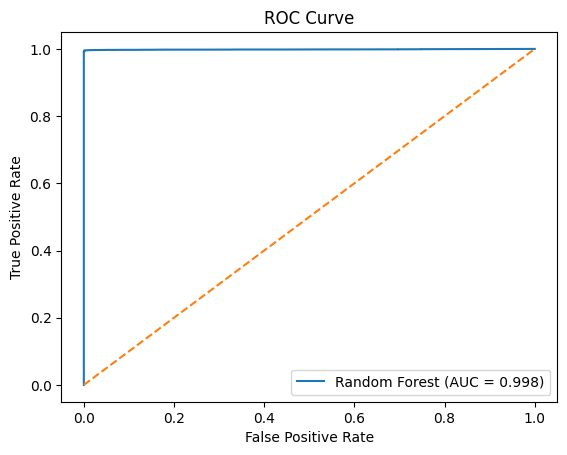

In [29]:
from sklearn.metrics import roc_curve, auc

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

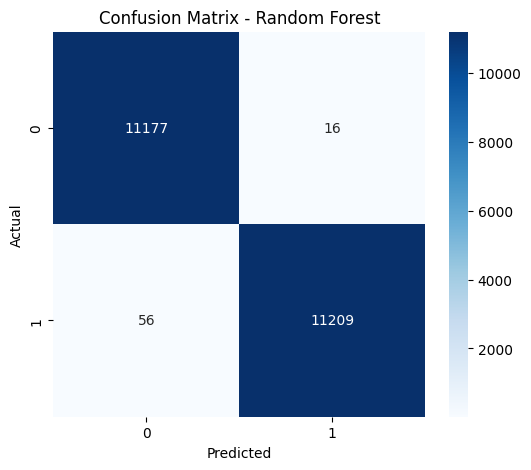

In [30]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Conclusion
All models performed well due to strong feature extraction and clear dataset patterns. Random Forest achieved the best performance due to its ability to handle complex relationships in data.

This system can be integrated with QR scanning applications to detect phishing threats in real time.

In [31]:
import pickle

pickle.dump(best_model, open("best_model.pkl", "wb"))